# NLP Mini Project: Traditional Text Classification Pipeline

## Project Overview

In this project, students will build a **complete traditional Natural Language Processing (NLP) machine learning pipeline** for text classification. The focus is on **classical NLP techniques** rather than deep learning.

Students will learn how to:

- Perform text preprocessing
- Apply classical NLP techniques
- Convert text into numerical features
- Train machine learning models
- Evaluate model performance
- Save preprocessing objects and trained models
- Deploy the trained model using a simple FastAPI service

---

## Learning Objectives

By completing this project, students will:

1. Understand the steps of a traditional NLP pipeline
2. Implement text preprocessing techniques
3. Convert text into vector representations (BOW / TF-IDF)
4. Train classical ML models for text classification
5. Evaluate models using proper metrics
6. Save preprocessing pipelines and models
7. Deploy the model as an API using FastAPI

---

# Dataset


### Kaggle Dataset (Optional)

Students may alternatively use an easy Kaggle dataset such as:

Spam Classification

https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Task:

Classify SMS messages as:

- spam
- ham

---

# Project Requirements

Students must implement the following pipeline:

1. Data loading
2. Text preprocessing
3. Feature extraction
4. Model training
5. Model evaluation
6. Saving artifacts
7. API deployment

---

# Step 1 — Install Required Libraries

Students may need the following libraries:

- pandas
- numpy
- scikit-learn
- nltk
- spacy
- fastapi
- uvicorn
- joblib

Hint: Install missing libraries using pip.


# Step 2 — Load Dataset

### Option A: Load the Kaggle dataset

Hint:

Your task:

- Load the dataset
- Convert it into a pandas DataFrame
- Inspect sample rows

Questions:

- How many documents are there?
- How many classes exist?


# Step 3 — Text Preprocessing

Students must implement the following preprocessing steps:

### 1. Case Folding

Convert text to lowercase.

Example:

`"Hello World" → "hello world"`

---

### 2. Remove Punctuation and Numbers

Use **Regular Expressions (re)**.

Hint:

Use `re.sub()`.

---

### 3. Tokenization

Split text into tokens.

Example:

`"machine learning is fun" → ["machine","learning","is","fun"]`

---

### 4. Stopword Removal

Remove common words such as:

- the
- is
- and

Hint:

Use NLTK stopwords.

---

### 5. Stemming

Apply a stemming algorithm.

Example:

- running → run
- played → play

Hint:

Use `PorterStemmer`.

---

### 6. Lemmatization

Convert words to dictionary form.

Example:

- better → good
- running → run

Hint:

Use `WordNetLemmatizer`.

---

### Task

Create a **single preprocessing function** that performs all steps.


# Step 4 — Feature Extraction

Convert text into numeric features.

Students must implement **two techniques**:

### 1. Bag of Words (BOW)

Hint:

`CountVectorizer`

---

### 2. TF-IDF

Hint:

`TfidfVectorizer`

---

Questions:

- What is the difference between BOW and TF-IDF?
- Which one performs better for your dataset?


# Step 5 — Train Machine Learning Models

Students must train **at least two models**.

Recommended models:

- Logistic Regression
- Naive Bayes
- Linear SVM

Hints:

Split the dataset using:

`train_test_split`

Train models on:

- BOW features
- TF-IDF features


# Step 6 — Model Evaluation

Students must evaluate models using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Hint:

Use:

`classification_report`

and

`confusion_matrix`

---

### Analysis Questions

Students must answer:

- Which model performed best?
- Did TF-IDF outperform BOW?
- Why might that happen?


# Step 7 — Save Preprocessing and Models

Students must save the following objects:

- text preprocessing pipeline
- vectorizer
- trained model

Use either:

- pickle
- joblib

Example files:

```
preprocessor.pkl
vectorizer.pkl
model.pkl
```

Hints:

Saving models allows reuse without retraining.


# Step 8 — Build a FastAPI Model Service

Students will create a simple **prediction API**.

### Goal

Send text → receive predicted class.

---

## Project Structure

Suggested folder structure:

```
nlp_project
│
├── model.pkl
├── vectorizer.pkl
├── preprocess.pkl
│
├── app.py
└── notebook.ipynb
```

---

## FastAPI Implementation Hints

Steps:

1. Load saved objects
2. Create API endpoint
3. Accept input text
4. Apply preprocessing
5. Vectorize text
6. Predict label
7. Return prediction

---

### Example Endpoint

`POST /predict`

Input:

```
{
  "text": "Free money!!! Click this link"
}
```

Output:

```
{
  "prediction": "spam"
}
```

---

### Run the API

Students should run:

```
uvicorn app:app --reload
```

Then open:

http://127.0.0.1:8000/docs

to test the API using Swagger UI.


# Bonus Tasks (Optional)

Students can extend the project by:

- Creating a scikit-learn Pipeline
- Performing hyperparameter tuning
- Adding model comparison plots
- Deploying the API with Docker
- Building a simple Streamlit UI


In [6]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib


In [7]:
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
df = pd.read_csv(r"/content/spam.csv", encoding="latin-1")

df = df[['v1','v2']]

df.columns = ['label','text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print("Number of documents:", len(df))

print("Classes:", df['label'].unique())

df['label'].value_counts()


Number of documents: 5572
Classes: ['ham' 'spam']


,count
label,
ham,4825
spam,747


In [10]:
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()


def preprocess(text):

    # lowercase
    text = text.lower()

    # remove punctuation & numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # tokenization
    tokens = text.split()

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [11]:
df['clean_text'] = df['text'].apply(preprocess)

df.head()

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [12]:
bow_vectorizer = CountVectorizer()

X_bow = bow_vectorizer.fit_transform(df['clean_text'])

X_bow.shape

(5572, 6198)

In [13]:
tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

X_tfidf.shape


(5572, 6198)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df['label'],
    test_size=0.2,
    random_state=42
)


In [15]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)


In [16]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [17]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [18]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))



Logistic Regression Accuracy: 0.9551569506726457
Naive Bayes Accuracy: 0.9659192825112107
SVM Accuracy: 0.979372197309417


In [19]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.98      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [20]:
print(confusion_matrix(y_test, y_pred_svm))

[[962   3]
 [ 20 130]]


In [21]:
joblib.dump(svm_model, "model.pkl")

joblib.dump(tfidf_vectorizer, "vectorizer.pkl")

joblib.dump(preprocess, "preprocess.pkl")


['preprocess.pkl']

In [23]:
sample = "Congratulations! You won a free prize"

clean = preprocess(sample)

vector = tfidf_vectorizer.transform([clean])

prediction = svm_model.predict(vector)

print(prediction)


['spam']


In [24]:
pip install fastapi uvicorn joblib

In [25]:
from fastapi import FastAPI
import joblib

app = FastAPI()

model = joblib.load("model.pkl")
vectorizer = joblib.load("vectorizer.pkl")
preprocess = joblib.load("preprocess.pkl")

@app.get("/")
def home():
    return {"message": "Spam Detection API is running"}

@app.post("/predict")
def predict(text: str):

    clean_text = preprocess(text)
    vector = vectorizer.transform([clean_text])
    prediction = model.predict(vector)

    return {"prediction": prediction[0]}



In [26]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Example: Pipeline with TF-IDF + SVM
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),  # TF-IDF
    ('classifier', LinearSVC())         # SVM
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

# Train pipeline
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)


In [27]:
rom sklearn.model_selection import GridSearchCV

param_grid = {
    'vectorizer__max_features': [500, 1000, 2000],
    'classifier__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best accuracy:", grid.best_score_)



SyntaxError: invalid syntax (334312788.py, line 1)

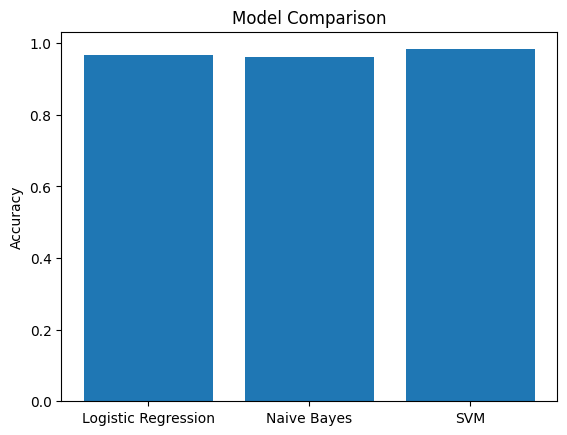

In [28]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('vectorizer', TfidfVectorizer()),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    acc = pipe.score(X_test, y_test)
    results[name] = acc

# Plot
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [29]:
import joblib

joblib.dump(svm_model, 'model.pkl')

joblib.dump(tfidf_vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']